In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

In [100]:

data = pd.read_csv('AMZN.csv')

data

,Date,Open,High,Low,Close,Adj Close,Volume
0,1997-05-15,0.121875,0.125000,0.096354,0.097917,0.097917,1443120000
1,1997-05-16,0.098438,0.098958,0.085417,0.086458,0.086458,294000000
2,1997-05-19,0.088021,0.088542,0.081250,0.085417,0.085417,122136000
3,1997-05-20,0.086458,0.087500,0.081771,0.081771,0.081771,109344000
4,1997-05-21,0.081771,0.082292,0.068750,0.071354,0.071354,377064000
...,...,...,...,...,...,...,...
6511,2023-03-30,101.550003,103.040001,101.010002,102.000000,102.000000,53633400
6512,2023-03-31,102.160004,103.489998,101.949997,103.290001,103.290001,56704300
6513,2023-04-03,102.300003,103.290001,101.430000,102.410004,102.410004,41135700
6514,2023-04-04,102.750000,104.199997,102.110001,103.949997,103.949997,48662500


In [101]:
data = data[['Date' , 'Close']]
data

,Date,Close
0,1997-05-15,0.097917
1,1997-05-16,0.086458
2,1997-05-19,0.085417
3,1997-05-20,0.081771
4,1997-05-21,0.071354
...,...,...
6511,2023-03-30,102.000000
6512,2023-03-31,103.290001
6513,2023-04-03,102.410004
6514,2023-04-04,103.949997


In [102]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cuda:0'

C:\Users\hp\AppData\Local\Temp\ipykernel_12584\365490723.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Date'] = pd.to_datetime(data['Date'])


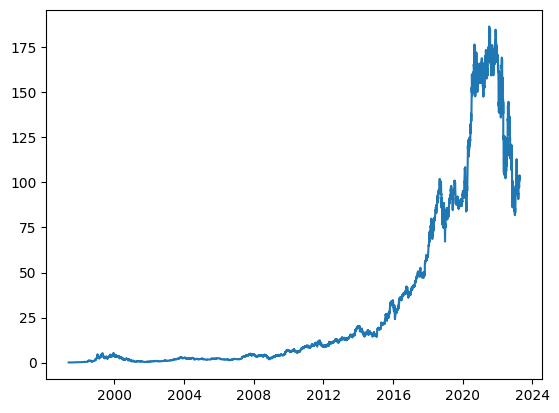

In [103]:
data['Date'] = pd.to_datetime(data['Date'])

plt.plot(data['Date'], data['Close'])

# plt.xlabel('Date')
# plt.ylabel('Close Price')
# plt.title('Amazon Closing Price')
# plt.show()

In [104]:
from copy import deepcopy as dc
import pandas as pd

def prepare_dataframe_for_lstm(df, n_steps):
    df = dc(df)
    df['Date'] = pd.to_datetime(df['Date'])
    
    df.set_index('Date', inplace=True)
    
    for i in range(1, n_steps+1):
        df[f'Close(t-{i})'] = df['Close'].shift(i)
        
    df.dropna(inplace=True)
    
    return df

lookback = 7
shifted_df = prepare_dataframe_for_lstm(data, lookback)
shifted_df

,Close,Close(t-1),Close(t-2),Close(t-3),Close(t-4),Close(t-5),Close(t-6),Close(t-7)
Date,,,,,,,,
1997-05-27,0.079167,0.075000,0.069792,0.071354,0.081771,0.085417,0.086458,0.097917
1997-05-28,0.076563,0.079167,0.075000,0.069792,0.071354,0.081771,0.085417,0.086458
1997-05-29,0.075260,0.076563,0.079167,0.075000,0.069792,0.071354,0.081771,0.085417
1997-05-30,0.075000,0.075260,0.076563,0.079167,0.075000,0.069792,0.071354,0.081771
1997-06-02,0.075521,0.075000,0.075260,0.076563,0.079167,0.075000,0.069792,0.071354
...,...,...,...,...,...,...,...,...
2023-03-30,102.000000,100.250000,97.239998,98.040001,98.129997,98.709999,98.699997,100.610001
2023-03-31,103.290001,102.000000,100.250000,97.239998,98.040001,98.129997,98.709999,98.699997
2023-04-03,102.410004,103.290001,102.000000,100.250000,97.239998,98.040001,98.129997,98.709999


In [105]:
shifted_df_as_np=shifted_df.to_numpy()
shifted_df_as_np

array([[7.91670000e-02, 7.50000000e-02, 6.97920000e-02, ...,
        8.54170000e-02, 8.64580000e-02, 9.79170000e-02],
       [7.65630000e-02, 7.91670000e-02, 7.50000000e-02, ...,
        8.17710000e-02, 8.54170000e-02, 8.64580000e-02],
       [7.52600000e-02, 7.65630000e-02, 7.91670000e-02, ...,
        7.13540000e-02, 8.17710000e-02, 8.54170000e-02],
       ...,
       [1.02410004e+02, 1.03290001e+02, 1.02000000e+02, ...,
        9.80400010e+01, 9.81299970e+01, 9.87099990e+01],
       [1.03949997e+02, 1.02410004e+02, 1.03290001e+02, ...,
        9.72399980e+01, 9.80400010e+01, 9.81299970e+01],
       [1.01099998e+02, 1.03949997e+02, 1.02410004e+02, ...,
        1.00250000e+02, 9.72399980e+01, 9.80400010e+01]], shape=(6509, 8))

In [106]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
shifted_df_as_np = scaler.fit_transform(shifted_df_as_np)

shifted_df_as_np

array([[-0.99991063, -0.99995531, -1.        , ..., -0.99983244,
        -0.99982128, -0.99969839],
       [-0.99993855, -0.99991063, -0.99994415, ..., -0.99987154,
        -0.99983244, -0.99982128],
       [-0.99995253, -0.99993855, -0.99989946, ..., -0.99998325,
        -0.99987154, -0.99983244],
       ...,
       [ 0.09747299,  0.10690997,  0.09308121, ...,  0.0506149 ,
         0.05158   ,  0.05779984],
       [ 0.11398769,  0.09747299,  0.10691495, ...,  0.04203581,
         0.0506149 ,  0.05158   ],
       [ 0.08342464,  0.11398769,  0.09747802, ...,  0.07431453,
         0.04203581,  0.0506149 ]], shape=(6509, 8))

In [107]:
X = shifted_df_as_np[:, 1:]
y = shifted_df_as_np[:, 0]

X.shape, y.shape

((6509, 7), (6509,))

In [108]:
 split_index = int(len(X) * 0.95)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6183, 7), (326, 7), (6183,), (326,))

In [109]:
X_train = torch.tensor(X_train).float().unsqueeze(-1)
y_train = torch.tensor(y_train).float()
X_test = torch.tensor(X_test).float().unsqueeze(-1)
y_test = torch.tensor(y_test).float()

# Verify the shapes! X_train should now be 3D: (6183, 7, 1)
print(X_train.shape, X_test.shape)

torch.Size([6183, 7, 1]) torch.Size([326, 7, 1])


In [110]:
from torch.utils.data import Dataset

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, i):
        return self.X[i], self.y[i]

    

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

In [111]:
from torch.utils.data import DataLoader

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [112]:
for _, batch in enumerate(train_loader):
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)
    break

torch.Size([16, 7, 1]) torch.Size([16])


In [113]:
import torch.nn as nn

class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_stacked_layers):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_stacked_layers = num_stacked_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_stacked_layers, 
                            batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        batch_size = x.size(0)
        
        # Dynamically match the device and data type of the incoming batch x
        h0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size, device=x.device, dtype=x.dtype)
        c0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size, device=x.device, dtype=x.dtype)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model = LSTM(1, 4, 1)
model.to(device)
model

LSTM(
  (lstm): LSTM(1, 4, batch_first=True)
  (fc): Linear(in_features=4, out_features=1, bias=True)
)

In [114]:
def train_one_epoch():
    model.train(True)
    print(f'Epoch: {epoch + 1}')
    running_loss = 0.0
    
    for batch_index, batch in enumerate(train_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)
        
        output = model(x_batch)
        loss = loss_function(output, y_batch)
        running_loss += loss.item() # Note: adding .item() is best practice to avoid accumulating history graphs
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if batch_index % 100 == 99: # print every 100 batches
            avg_loss_across_batches = running_loss / 100
            print('Batch {0}, Loss: {1:.3f}'.format(batch_index + 1, avg_loss_across_batches))
            running_loss = 0.0
            
    print()

In [115]:
def validate_one_epoch():
    model.train(False)
    running_loss = 0.0
    
    for batch_index, batch in enumerate(test_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)
        
        with torch.no_grad():
            output = model(x_batch)
            loss = loss_function(output, y_batch)
            running_loss += loss.item() # Using .item() here is also highly recommended
            
    avg_loss_across_batches = running_loss / len(test_loader)
    
    print('Val Loss: {0:.3f}'.format(avg_loss_across_batches))
    print('***************************************************')
    print()

In [116]:
learning_rate = 0.001
num_epochs = 10
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    train_one_epoch()
    validate_one_epoch()

Epoch: 1


C:\Users\hp\miniconda3\envs\ml_env\lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([16])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Batch 100, Loss: 0.675
Batch 200, Loss: 0.299
Batch 300, Loss: 0.223


C:\Users\hp\miniconda3\envs\ml_env\lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([7])) that is different to the input size (torch.Size([7, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
C:\Users\hp\miniconda3\envs\ml_env\lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([6])) that is different to the input size (torch.Size([6, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)



Val Loss: 1.125
***************************************************

Epoch: 2
Batch 100, Loss: 0.237
Batch 200, Loss: 0.218
Batch 300, Loss: 0.214

Val Loss: 1.046
***************************************************

Epoch: 3
Batch 100, Loss: 0.245
Batch 200, Loss: 0.221
Batch 300, Loss: 0.225

Val Loss: 1.023
***************************************************

Epoch: 4
Batch 100, Loss: 0.221
Batch 200, Loss: 0.239
Batch 300, Loss: 0.220

Val Loss: 1.021
***************************************************

Epoch: 5
Batch 100, Loss: 0.211
Batch 200, Loss: 0.238
Batch 300, Loss: 0.205

Val Loss: 0.944
***************************************************

Epoch: 6
Batch 100, Loss: 0.221
Batch 200, Loss: 0.221
Batch 300, Loss: 0.226

Val Loss: 0.974
***************************************************

Epoch: 7
Batch 100, Loss: 0.225
Batch 200, Loss: 0.233
Batch 300, Loss: 0.236

Val Loss: 1.021
***************************************************

Epoch: 8
Batch 100, Loss: 0.213
Batch 200,

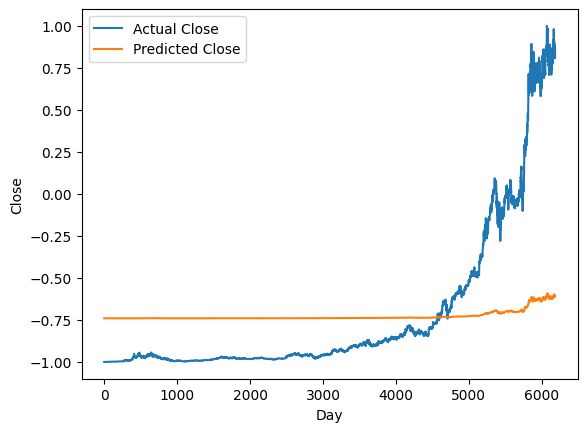

In [117]:
with torch.no_grad():
    predicted = model(X_train.to(device)).to('cpu').numpy()

plt.plot(y_train, label='Actual Close')
plt.plot(predicted, label='Predicted Close')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.show()

In [118]:
train_predictions = predicted.flatten()

dummies = np.zeros((X_train.shape[0], lookback+1))
dummies[:, 0] = train_predictions
dummies = scaler.inverse_transform(dummies)

train_predictions = dc(dummies[:, 0])
train_predictions

array([24.27316305, 24.27302966, 24.27299075, ..., 36.25637082,
       36.42369811, 36.60151358], shape=(6183,))

In [119]:
test_predictions = model(X_test.to(device)).to('cpu').detach().numpy().flatten()

dummies = np.zeros((X_test.shape[0], lookback+1))
dummies[:, 0] = test_predictions
dummies = scaler.inverse_transform(dummies)

test_predictions = dc(dummies[:, 0])
test_predictions

array([36.47381015, 36.27196691, 36.09350669, 35.96994406, 35.9932048 ,
       36.1064071 , 35.89683807, 35.94029147, 35.88078621, 36.04920289,
       36.04189952, 36.00222008, 35.91603026, 35.8909798 , 35.75871315,
       35.66695409, 35.55575273, 35.59691619, 35.34905725, 35.14926495,
       35.08156701, 35.04072037, 35.01393021, 35.07856563, 34.84998226,
       34.50141568, 34.2825757 , 33.8642658 , 33.46165204, 33.01952558,
       32.61946856, 32.66023183, 32.53746957, 32.59668025, 32.83864758,
       33.2048612 , 33.5312453 , 33.64103491, 33.65579172, 33.58028462,
       34.49071074, 34.53320259, 34.62292181, 34.48586961, 34.26336683,
       34.02443979, 34.08106039, 34.07915396, 34.0106223 , 33.75906165,
       33.59814843, 33.47453577, 33.3895743 , 33.69855036, 33.70009552,
       33.52789375, 33.28574856, 33.13926979, 32.81357489, 32.57042924,
       32.29141702, 32.42553453, 32.77712472, 33.17827669, 33.24197834,
       33.39731677, 33.93134679, 34.40589934, 34.75316531, 35.02

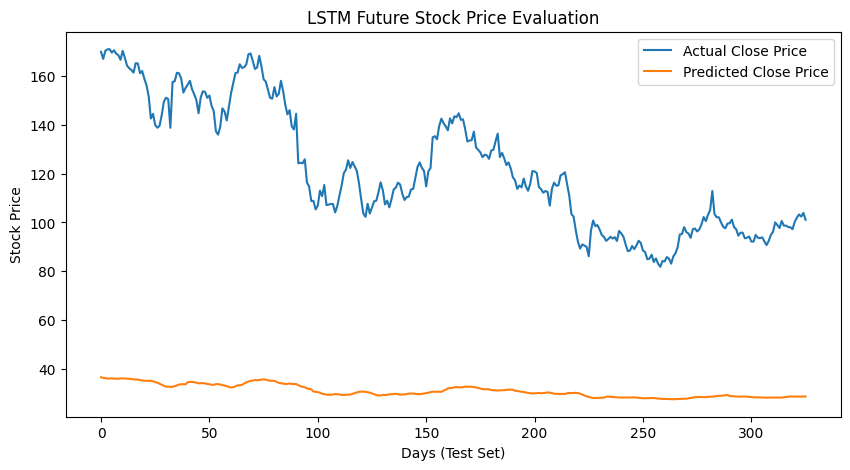

In [121]:
# Unscale y_test for an accurate visualization comparison
true_dummies = np.zeros((y_test.shape[0], lookback+1))
true_dummies[:, 0] = y_test.numpy()
true_dummies = scaler.inverse_transform(true_dummies)
unscaled_y_test = dc(true_dummies[:, 0])

# Plot the results
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(unscaled_y_test, label='Actual Close Price')
plt.plot(test_predictions, label='Predicted Close Price')
plt.xlabel('Days (Test Set)')
plt.ylabel('Stock Price')
plt.title('LSTM Future Stock Price Evaluation')
plt.legend()
plt.show()

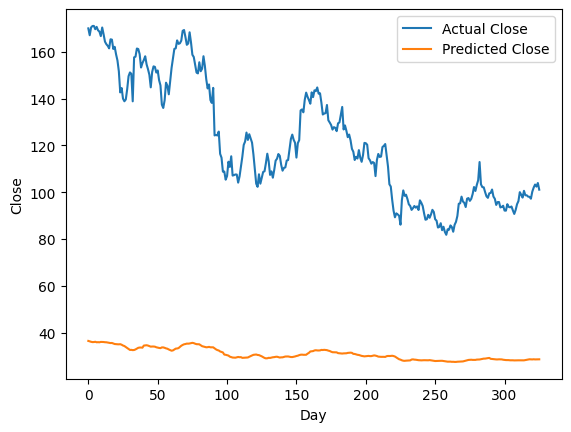

In [122]:
plt.plot(unscaled_y_test, label='Actual Close')
plt.plot(test_predictions, label='Predicted Close')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.show()

In [123]:
plt.plot(index_with_lagged_dropped, unscaled_y, label='Actual Close')
plt.plot(index_with_lagged_dropped, full_predictions, label='Predicted Close')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.show()

NameError: name 'index_with_lagged_dropped' is not defined

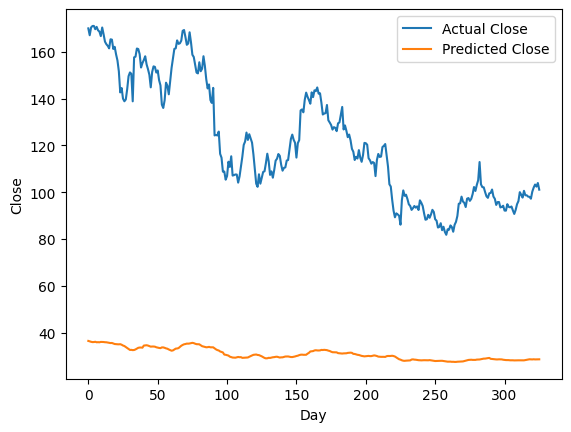

In [124]:
plt.plot(unscaled_y_test, label='Actual Close')
plt.plot(test_predictions, label='Predicted Close')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.show()

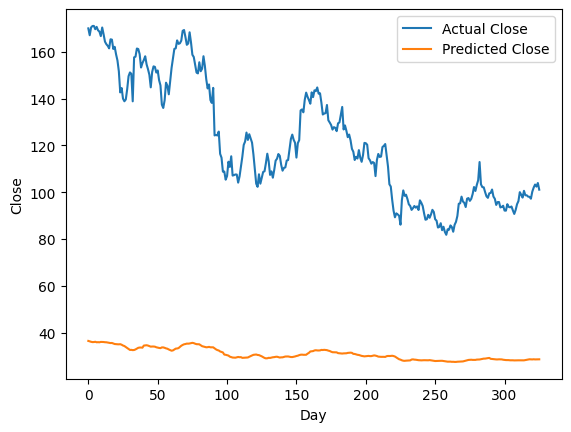

In [125]:
plt.plot(unscaled_y_test, label='Actual Close')
plt.plot(test_predictions, label='Predicted Close')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.show()